<a href="https://colab.research.google.com/github/Omen4Dead/DL_lessons/blob/main/predict_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Проверяем, что мы находимся в collab перед установкой tensorflow
try:
  import google.colab
  !pip install tensorflow
  IS_COLAB_ENV = True
  print("Install tensorflow")
except:
  IS_COLAB_ENV = False
  print("Not in collab.")

Install tensorflow


In [13]:
# Установка библиотек
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Скачиваем изображение
IMG_PATH = '../../sample-images/cat.jpg'
if IS_COLAB_ENV:
  !curl https://raw.githubusercontent.com/PracticalDL/Practical-Deep-Learning-Book/master/sample-images/cat.jpg --output cat.jpg
  IMG_PATH = 'cat.jpg'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  661k  100  661k    0     0  2143k      0 --:--:-- --:--:-- --:--:-- 2148k


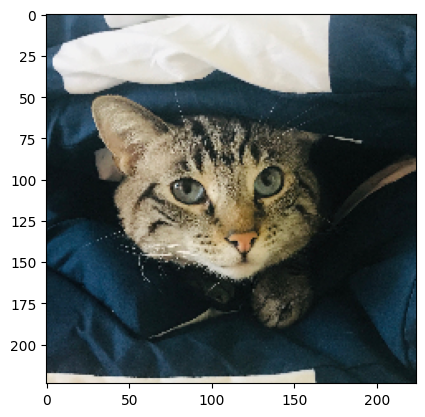

In [7]:
# Выводим, для наглядности через matplotlib.pyplot
img = image.load_img(IMG_PATH, target_size=(224, 224))
plt.imshow(img)
plt.show()

In [8]:
# При вызове этого метода API tensorflow
# автоматически скачивает и подгружает модель ResNet50
model = tf.keras.applications.resnet50.ResNet50()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# Функция для нормализации изображения
def predict(img_path):
    # стандартный размер для работы библиотеки - 224х224 пикселя
    img = image.load_img(img_path, target_size=(224, 224))
    model = tf.keras.applications.resnet50.ResNet50()
    # Увеличиваем кол-во измерений, потому что на вход ожидается
    # не единственное изображение, а массив с изображениями
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)

    prediction = model.predict(img_preprocessed)
    print(decode_predictions(prediction, top=3)[0])


predict(IMG_PATH)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[('n02123045', 'tabby', np.float32(0.57197636)), ('n02124075', 'Egyptian_cat', np.float32(0.21763526)), ('n02123159', 'tiger_cat', np.float32(0.060934342))]


In [15]:
IMG_PATH_2 = ''
if IS_COLAB_ENV:
  !curl https://raw.githubusercontent.com/PracticalDL/Practical-Deep-Learning-Book/master/sample-images/dog.jpg --output dog.jpg
  IMG_PATH_2 = 'dog.jpg'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2231k  100 2231k    0     0  3509k      0 --:--:-- --:--:-- --:--:-- 3509k


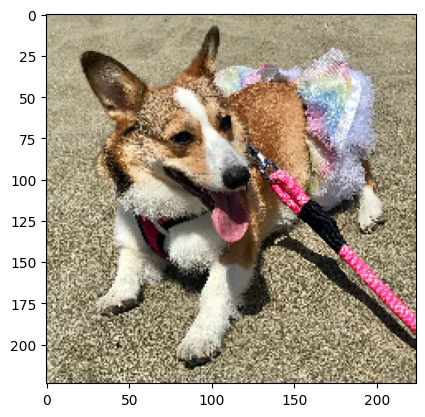

In [16]:
img = image.load_img(IMG_PATH_2, target_size=(224, 224))
plt.imshow(img)
plt.show()

In [17]:
predict(IMG_PATH_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[('n02113186', 'Cardigan', np.float32(0.83496803)), ('n02113023', 'Pembroke', np.float32(0.15543458)), ('n02110806', 'basenji', np.float32(0.0028011086))]
